In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline
import datetime

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

In [2]:
# Visualization helper function taken from https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb
def plot_forecast(
    context_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_column: str,
    timeseries_id: str,
    id_column: str = "id",
    timestamp_column: str = "timestamp",
    history_length: int = 256,
    title_suffix: str = "",
):
    ts_context = context_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]
    ts_pred = pred_df.query(f"{id_column} == @timeseries_id and target_name == @target_column").set_index(
        timestamp_column
    )[["0.1", "predictions", "0.9"]]
    ts_ground_truth = test_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]

    last_date = ts_context.index.max()
    start_idx = max(0, len(ts_context) - history_length)
    plot_cutoff = ts_context.index[start_idx]
    ts_context = ts_context[ts_context.index >= plot_cutoff]
    ts_pred = ts_pred[ts_pred.index >= plot_cutoff]
    ts_ground_truth = ts_ground_truth[ts_ground_truth.index >= plot_cutoff]

    fig = plt.figure(figsize=(12, 3))
    ax = fig.gca()
    ts_context.plot(ax=ax, label=f"historical {target_column}", color="xkcd:azure")
    ts_ground_truth.plot(ax=ax, label=f"future {target_column} (ground truth)", color="xkcd:grass green")
    ts_pred["predictions"].plot(ax=ax, label="forecast", color="xkcd:violet")
    ax.fill_between(
        ts_pred.index,
        ts_pred["0.1"],
        ts_pred["0.9"],
        alpha=0.7,
        label="prediction interval",
        color="xkcd:light lavender",
    )
    ax.axvline(x=last_date, color="black", linestyle="--", alpha=0.5)
    ax.legend(loc="upper left")
    ax.set_title(f"{target_column} forecast for {timeseries_id} {title_suffix}")
    fig.show()

    fig.savefig(f"/home/cloudsherpa-collab/forecast_plots/forecast-{datetime.datetime.now()}.png", dpi=300, bbox_inches='tight')

In [3]:
def sherpa_chronos_preprocess(
    path: str
):
    rename_columns = {
        "resourceId": "item_id",
        "value": "target"
    }

    keep_columns = ["resourceId", "value", "metricName", "timestamp"]

    # Not handling FileNotFoundError, want runtime error to be thrown if that happens
    context_df = pd.read_csv(path)
    
    context_df = context_df[keep_columns].copy()
    context_df = context_df.rename(columns=rename_columns)

    context_df["timestamp"] = pd.to_datetime(context_df['timestamp'], format='ISO8601', utc=True).dt.tz_convert("UTC").dt.tz_localize(None)
    context_df = context_df.dropna(subset=["timestamp"])
    
    return context_df

def sherpa_get_feature(
    context_df: pd.DataFrame,
    resource_id: str,
    metricName: str,
):
    return context_df.loc[(context_df["item_id"] == resource_id) & (context_df["metricName"] == metricName)].copy()
    

In [4]:
mock_context_df = sherpa_chronos_preprocess("datasets/mockDataset.csv")
print(mock_context_df.shape)
print(mock_context_df.head())

(160722, 4)
               item_id        target      metricName           timestamp
0  i-0ec321a1c8ed4915c     44.108112  CPUUtilization 2026-05-01 00:00:00
1  i-0ec321a1c8ed4915c  71729.757132       NetworkIn 2026-05-01 00:00:00
2  i-0ec321a1c8ed4915c  75786.312647   DiskReadBytes 2026-05-01 00:00:00
3  i-0ec321a1c8ed4915c     32.426750  CPUUtilization 2026-05-01 00:05:00
4  i-0ec321a1c8ed4915c  64688.834524       NetworkIn 2026-05-01 00:05:00


# Test Univariate with Mock Data

In [5]:
mock_cpu_df = sherpa_get_feature(mock_context_df, "i-0ec321a1c8ed4915c", "CPUUtilization")
display(mock_cpu_df.shape)
test_size=612
mock_cpu_train = mock_cpu_df.iloc[:-test_size].copy()
mock_cpu_test = mock_cpu_df.iloc[-test_size:].copy()
display(mock_cpu_train.shape)
display(mock_cpu_test.shape)
display(mock_cpu_test.tail())

(8929, 4)

(8317, 4)

(612, 4)

,item_id,target,metricName,timestamp
156372,i-0ec321a1c8ed4915c,45.445015,CPUUtilization,2026-05-31 23:40:00
156375,i-0ec321a1c8ed4915c,39.570892,CPUUtilization,2026-05-31 23:45:00
156378,i-0ec321a1c8ed4915c,33.288518,CPUUtilization,2026-05-31 23:50:00
156381,i-0ec321a1c8ed4915c,35.113337,CPUUtilization,2026-05-31 23:55:00
156384,i-0ec321a1c8ed4915c,20.049814,CPUUtilization,2026-06-01 00:00:00


In [6]:
# Make prediction
pred_df = pipeline.predict_df(mock_cpu_train, prediction_length=test_size, quantile_levels=[0.1, 0.5, 0.9], freq="5min")
print(pred_df.iloc[0])

item_id        i-0ec321a1c8ed4915c
timestamp      2026-05-29 21:05:00
target_name                 target
predictions              23.475277
0.1                       19.42123
0.5                      23.475277
0.9                      29.900824
Name: 0, dtype: object


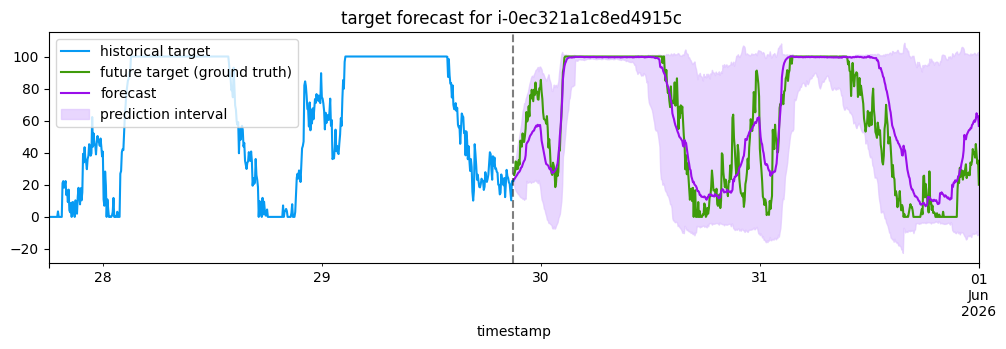

In [7]:
plot_forecast(
    context_df=mock_cpu_train,
    pred_df=pred_df,
    test_df=mock_cpu_test,
    target_column="target",
    timeseries_id="i-0ec321a1c8ed4915c",
    id_column="item_id",
    timestamp_column="timestamp",
    history_length=612,
)

# Test Historical Covariate with Mock Data

In [8]:
mock_context_df.loc[(mock_context_df["item_id"] == "i-0ec321a1c8ed4915c")]["metricName"].unique()

mock_cpu_df = sherpa_get_feature(mock_context_df, "i-0ec321a1c8ed4915c", "CPUUtilization").drop(columns=["metricName"])
mock_network_in_df = sherpa_get_feature(mock_context_df, "i-0ec321a1c8ed4915c", "NetworkIn").drop(columns=["metricName"])
mock_disk_read_df = sherpa_get_feature(mock_context_df, "i-0ec321a1c8ed4915c", "DiskReadBytes").drop(columns=["metricName"])

mock_network_in_df = mock_network_in_df.rename(columns={"target": "NetworkIn"})
mock_disk_read_df = mock_disk_read_df.rename(columns={"target": "DiskRead"})

covariate_df = (
    mock_cpu_df
    .merge(mock_network_in_df, on=["item_id", "timestamp"])
    .merge(mock_disk_read_df, on=["item_id", "timestamp"])
)

print(covariate_df.info())
print(covariate_df[0:5])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8929 entries, 0 to 8928
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   item_id    8929 non-null   object        
 1   target     8929 non-null   float64       
 2   timestamp  8929 non-null   datetime64[ns]
 3   NetworkIn  8929 non-null   float64       
 4   DiskRead   8929 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 348.9+ KB
None
               item_id     target           timestamp     NetworkIn  \
0  i-0ec321a1c8ed4915c  44.108112 2026-05-01 00:00:00  71729.757132   
1  i-0ec321a1c8ed4915c  32.426750 2026-05-01 00:05:00  64688.834524   
2  i-0ec321a1c8ed4915c  29.943384 2026-05-01 00:10:00  51356.239597   
3  i-0ec321a1c8ed4915c  28.484825 2026-05-01 00:15:00  44419.348569   
4  i-0ec321a1c8ed4915c  28.690147 2026-05-01 00:20:00  32927.378964   

       DiskRead  
0  75786.312647  
1  60898.705671  
2  552

In [9]:
test_size=612
mock_covariate_train = covariate_df.iloc[:-test_size].copy()
mock_covariate_test = covariate_df.iloc[-test_size:].copy()

In [10]:
pred_df = pipeline.predict_df(mock_covariate_train, prediction_length=test_size, quantile_levels=[0.1, 0.5, 0.9], target="target")

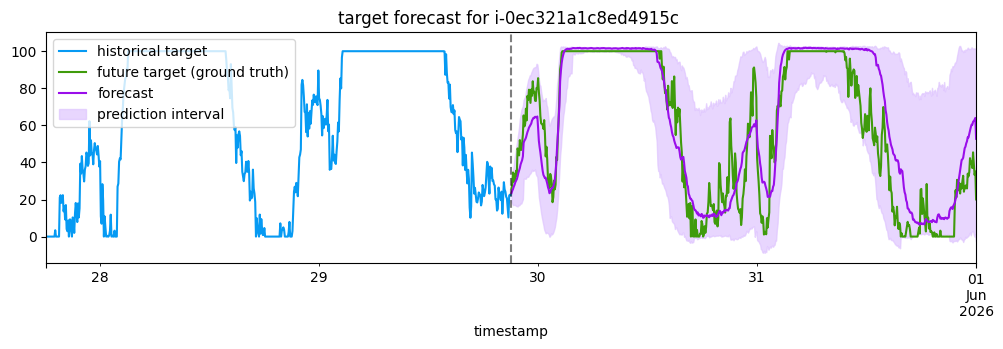

In [11]:
plot_forecast(
    context_df=mock_covariate_train,
    pred_df=pred_df,
    test_df=mock_covariate_test,
    target_column="target",
    timeseries_id="i-0ec321a1c8ed4915c",
    id_column="item_id",
    timestamp_column="timestamp",
    history_length=612,
)